In [6]:
!sudo apt install tesseract-ocr
!pip install pytesseract opencv-python matplotlib kaggle

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [7]:
import cv2
import pytesseract
import os
import matplotlib.pyplot as plt
from difflib import SequenceMatcher

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
folder_path = "/content/drive/MyDrive/OCR_Project/dataset"

In [10]:
def similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

In [27]:
def process_image(img_path):
    import cv2
    import pytesseract

    # Read image
    img = cv2.imread(img_path)

    # Custom OCR config (better accuracy)
    custom_config = r'--oem 3 --psm 6'

    # OCR on original image
    original_text = pytesseract.image_to_string(img, config=custom_config)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_text = pytesseract.image_to_string(gray, config=custom_config)

    # Apply thresholding
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
    thresh_text = pytesseract.image_to_string(thresh, config=custom_config)

    # Bounding boxes (on original image)
    boxed_img = img.copy()
    h, w, _ = boxed_img.shape

    boxes = pytesseract.image_to_boxes(img, config=custom_config)

    for b in boxes.splitlines():
        b = b.split(' ')
        x, y, x2, y2 = int(b[1]), int(b[2]), int(b[3]), int(b[4])
        cv2.rectangle(boxed_img, (x, h - y), (x2, h - y2), (0, 255, 0), 2)

    return original_text, gray_text, thresh_text, boxed_img, gray, thresh

In [34]:
folder_path = "/content/drive/MyDrive/OCR_Project/dataset"

results = []

for img_name in os.listdir(folder_path)[:20]:
    img_path = os.path.join(folder_path, img_name)

    original, gray, thresh, img, g_img, t_img = process_image(img_path)


    ground_truth = img_name.split('.')[0]

    acc1 = similarity(ground_truth, original)
    acc2 = similarity(ground_truth, gray)
    acc3 = similarity(ground_truth, thresh)

    results.append([acc1, acc2, acc3])

In [35]:
import numpy as np

results = np.array(results)

avg_original = np.mean(results[:,0])
avg_gray = np.mean(results[:,1])
avg_thresh = np.mean(results[:,2])

print("Original Accuracy:", avg_original)
print("Grayscale Accuracy:", avg_gray)
print("Threshold Accuracy:", avg_thresh)

Original Accuracy: 0.1355298630373593
Grayscale Accuracy: 0.1355298630373593
Threshold Accuracy: 0.13210549200691624


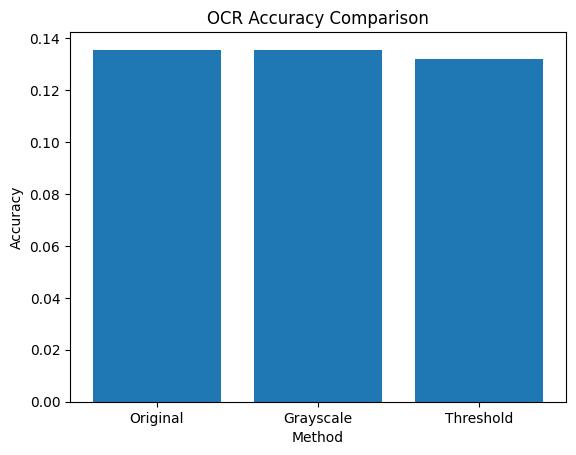

In [36]:
methods = ['Original', 'Grayscale', 'Threshold']
accuracy = [avg_original, avg_gray, avg_thresh]
boxes = pytesseract.image_to_boxes(img)

plt.figure()
plt.bar(methods, accuracy)
plt.xlabel("Method")
plt.ylabel("Accuracy")
plt.title("OCR Accuracy Comparison")
plt.show()

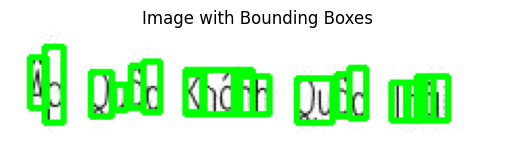

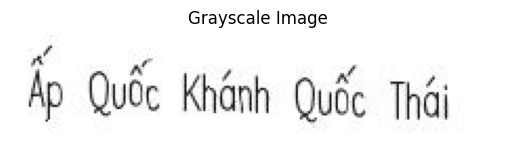

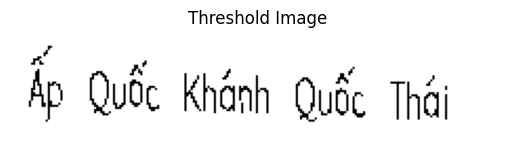

Original OCR:
 fy Qube Khénh usc Thai

After Preprocessing:
 fh Qube Khésh Qué Ta



In [38]:
img_path = os.path.join(folder_path, os.listdir(folder_path)[7])

original, gray, thresh, img, g_img, t_img = process_image(img_path)

# Original Image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Image with Bounding Boxes")
plt.axis('off')
plt.show()

# Grayscale
plt.imshow(g_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

# Threshold
plt.imshow(t_img, cmap='gray')
plt.title("Threshold Image")
plt.axis('off')
plt.show()

print("Original OCR:\n", original)
print("After Preprocessing:\n", thresh)